In [41]:
import matplotlib.pyplot as plt
import torch
from PIL import Image
import torchvision.transforms as T
import numpy as np
import pandas as pd
import os
from torch.utils.data import Dataset, DataLoader, random_split

## 自定义数据集类

In [47]:
class NoiseImageDataset(Dataset):
    #初始化
    def __init__(self,image_dir,transform=None):
        self.image_dir=image_dir
        self.transform=transform
        self.image_names=os.listdir(image_dir)

    #获取数据集长度
    def __len__(self):
        return len(self.image_names)

    #根据索引号获取元素:(input,target)=(noise_image,image)
    def __getitem__(self,idx):
        #1.构建图片的网站访问路径
        image_path=os.path.join(self.image_dir,self.image_names[idx])
        #2.打开图片
        image=Image.open(image_path).convert("RGB")
        #3.图像转换,(调整大小,转换Tensor)
        if self.transform is not None:
            img_tensor=self.transform(image)
        else:#(抛出异常)
            raise ValueError("transform 参数不能为None!")
        #4.加入噪声,得到模型输入的input
        noise_factor=0.5
        image_noise_tensor=img_tensor+noise_factor*torch.randn_like(img_tensor)
        #将图片数据范围限制在(0,1)
        image_noise_tensor=torch.clamp(image_noise_tensor,0,1)
        return image_noise_tensor,img_tensor



In [57]:
transform=T.Compose([#排版
    T.Resize((64,64)),
    T.ToTensor(),#直接归一化+float
])

dataset=NoiseImageDataset(image_dir='../common/dataset/',transform=transform)
# print(dataset.image_names)

In [32]:
print(dataset[0][0].shape)
# print(np.dtype(dataset))
# print(np.dtype(dataset[0]))
# print(np.dtype(dataset[0][0]))
print(dataset[0][0])
print(dataset[0])

torch.Size([3, 64, 64])
tensor([[[1.0000, 1.0000, 0.4475,  ..., 0.0552, 0.8554, 1.0000],
         [1.0000, 1.0000, 1.0000,  ..., 1.0000, 1.0000, 0.4198],
         [1.0000, 0.2164, 0.8812,  ..., 0.8068, 1.0000, 0.2073],
         ...,
         [1.0000, 1.0000, 1.0000,  ..., 0.6304, 0.4679, 1.0000],
         [1.0000, 0.6098, 1.0000,  ..., 1.0000, 1.0000, 1.0000],
         [1.0000, 0.7089, 0.7494,  ..., 0.3227, 0.9851, 1.0000]],

        [[1.0000, 1.0000, 1.0000,  ..., 1.0000, 1.0000, 0.0000],
         [1.0000, 0.5179, 1.0000,  ..., 0.3728, 0.0000, 0.7679],
         [0.0000, 0.0000, 1.0000,  ..., 0.3482, 1.0000, 0.8844],
         ...,
         [1.0000, 0.0627, 0.8055,  ..., 1.0000, 1.0000, 1.0000],
         [0.3626, 1.0000, 1.0000,  ..., 1.0000, 0.7864, 0.5995],
         [0.5590, 1.0000, 0.9614,  ..., 0.6583, 0.4568, 1.0000]],

        [[0.0166, 1.0000, 0.4651,  ..., 1.0000, 0.8905, 0.5679],
         [1.0000, 1.0000, 1.0000,  ..., 0.4718, 1.0000, 1.0000],
         [0.7192, 1.0000, 0.0000, 


## 划分数据集,构建加载器


In [58]:
#划分数据集
train_dataset,val_dataset,test_dataset=random_split(dataset,[0.7,0.15,0.15])
#构建加载器
train_dataset_loader=DataLoader(train_dataset,batch_size=32,shuffle=True,drop_last=True)
val_dataset_loader=DataLoader(val_dataset,batch_size=32)
test_dataset_loader=DataLoader(test_dataset,batch_size=32)


In [55]:

print(next(iter(train_dataset_loader))[0].shape)
print(next(iter(train_dataset_loader))[1].shape)

torch.Size([32, 3, 64, 64])
torch.Size([32, 3, 64, 64])


## 定义模型

In [33]:
from torch import nn,optim

In [34]:
#自定义神经网络类:基于CNN的去噪器
class ConvDeNoiser(nn.Module):
    def __init__(self):
        super(ConvDeNoiser,self).__init__()
        #编码器
            #卷积层
        self.conv1=nn.Conv2d(in_channels=3,out_channels=32,kernel_size=3,stride=1,padding=1)
        self.conv2=nn.Conv2d(in_channels=32,out_channels=16,kernel_size=3,stride=1,padding=1)
        self.conv3=nn.Conv2d(in_channels=16,out_channels=8,kernel_size=3,stride=1,padding=1)
        #通用池化层
        self.pool=nn.MaxPool2d(kernel_size=2,stride=2)
        #解码器
        #转置卷积成
        self.conv_t1=nn.ConvTranspose2d(in_channels=8,out_channels=8,kernel_size=3,stride=2,padding=1,output_padding=1)
        self.conv_t2=nn.ConvTranspose2d(in_channels=8,out_channels=16,kernel_size=3,stride=2,padding=1,output_padding=1)
        self.conv_t3=nn.ConvTranspose2d(in_channels=16,out_channels=32,kernel_size=3,stride=2,padding=1,output_padding=1)
        #输出普通卷积层
        self.conv_out=nn.Conv2d(in_channels=32,out_channels=3,kernel_size=3,stride=1,padding=1)

    def forward(self,x):
        #编码
        #第一次卷积,激活,池化
        x=torch.relu(self.conv1(x))
        x=self.pool(x)

        #第二次卷积,激活,池化
        x=torch.relu(self.conv2(x))
        x=self.pool(x)

        #第三次卷积,激活,池化
        x=torch.relu(self.conv3(x))
        x=self.pool(x)

        #解码
        #第一次转置卷积
        x=torch.relu(self.conv_t1(x))

        #第二次转置卷积
        x=torch.relu(self.conv_t2(x))

        #第三次转置卷积
        x=torch.relu(self.conv_t3(x))

        #最终输出:sigmoid限制在0-1
        y=torch.sigmoid(self.conv_out(x))

        return y


In [43]:
model=ConvDeNoiser()
print(model)

ConvDeNoiser(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(16, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv_t1): ConvTranspose2d(8, 8, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
  (conv_t2): ConvTranspose2d(8, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
  (conv_t3): ConvTranspose2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
  (conv_out): Conv2d(32, 3, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
)


In [37]:
#前向传播测试
input=torch.randn(3,64,64)
output=model(input)
print(output.shape)

torch.Size([3, 128, 128])


## 训练模型


In [45]:
#1.定义设备
device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)
#2.损失函数
loss_fn=nn.MSELoss()
#3.定义超参数
lr=0.001
epochs=5
#3.优化器
optimizer=optim.Adam(model.parameters(),lr=lr)


In [59]:
#4.训练
train_loss=0
for epoch in range(epochs):
    model.train()
    total_loss=0
    for noise_img,img in train_dataset_loader:
        input=noise_img.to(device)
        target=img.to(device)

        #前向传播
        output=model(input)
        #计算损失
        loss=loss_fn(output,target)
        #反向传播
        loss.backward()
        #更新参数
        optimizer.step()
        #梯度清零
        optimizer.zero_grad()
        #累加本轮的梯度
        total_loss+=loss.item()
    #本轮训练完成,计算本轮的平均损失
    train_loss=total_loss/len(train_dataset_loader)
    print(f"Epoch:{epoch+1},Trian Loss:{train_loss}")


Epoch:1,Trian Loss:0.030623681594585075
Epoch:2,Trian Loss:0.011918852021694732
Epoch:3,Trian Loss:0.0107154647029017
Epoch:4,Trian Loss:0.010194487902327246
Epoch:5,Trian Loss:0.009853650313248072
Epoch:6,Trian Loss:0.009516207411247228
Epoch:7,Trian Loss:0.008535921571923772
Epoch:8,Trian Loss:0.007993792814012225
Epoch:9,Trian Loss:0.007793937761741338
Epoch:10,Trian Loss:0.007670144025668584
Epoch:11,Trian Loss:0.007560726759430454
Epoch:12,Trian Loss:0.007467761149537333
Epoch:13,Trian Loss:0.007371517977956854
Epoch:14,Trian Loss:0.007302977898523458
Epoch:15,Trian Loss:0.007237602114457891
Epoch:16,Trian Loss:0.007161765405650955
Epoch:17,Trian Loss:0.00713239017784815
Epoch:18,Trian Loss:0.007072825579085897
Epoch:19,Trian Loss:0.007032902979053571
Epoch:20,Trian Loss:0.006980263429966585
Epoch:21,Trian Loss:0.0069356004040324664
Epoch:22,Trian Loss:0.0068942475506545324
Epoch:23,Trian Loss:0.006868154126944957
Epoch:24,Trian Loss:0.006834817940496169
Epoch:25,Trian Loss:0.0067

## 测试

In [61]:
test_iter=iter(test_dataset_loader)
test_noise_imgs,test_imgs = next(test_iter)
with torch.no_grad():
    model.eval()
    inputs=test_noise_imgs.to(device)
    target=test_imgs.to(device)
    output=model(inputs)
output=output.permute(0,2,3,1).cpu().numpy()
test_noise_imgs=test_noise_imgs.permute(0,2,3,1).numpy()
test_imgs=test_imgs.permute(0,2,3,1).numpy()

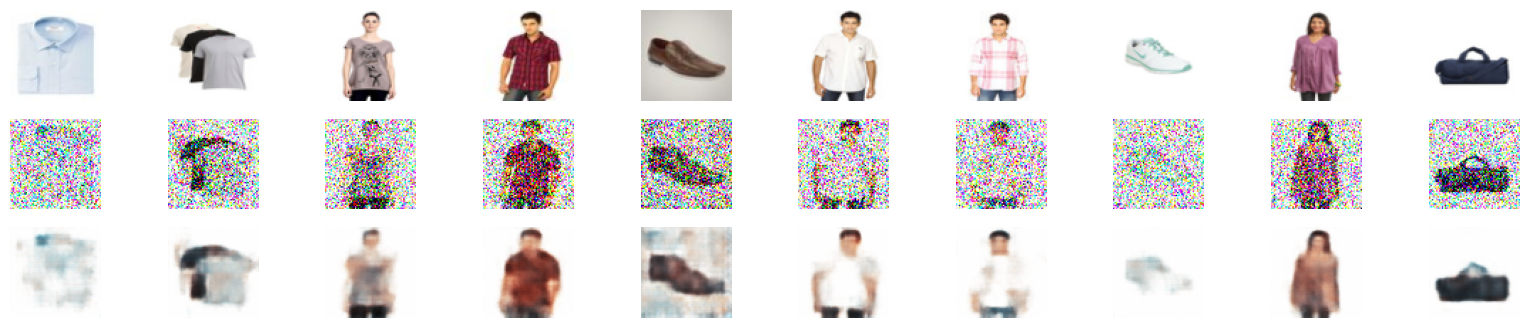

In [63]:
#画图
import matplotlib.pyplot as plt
fig,axes=plt.subplots(3,10,figsize=(20,4),sharex=True,sharey=True)
for rows,imgs in zip(axes,[test_imgs,test_noise_imgs,output]):
    for row ,img in zip(rows,imgs):
        row.imshow(img)
        row.set_axis_off()
plt.show()

## 文件名排序


In [39]:
import re

def sort_filenames_by_number(filenames):
    """
    对文件名列表按照其中的数字进行排序
    :param filenames: 文件名列表
    :return: 排序后的文件名列表
    """
    # 定义一个函数，用于提取文件名中的数字并转换为整数
    def extract_number(filename):
        match = re.search(r'\d+', filename)  # 匹配文件名中的数字
        return int(match.group()) if match else 0  # 返回数字，如果没有数字则返回0

    # 使用 sorted 函数和自定义排序键进行排序
    sorted_filenames = sorted(filenames, key=extract_number)
    return sorted_filenames

# 测试示例
filenames = ['0.jpg', '1.jpg', '10.jpg', '100.jpg', '1000.jpg', '10000.jpg','2.jpg']
sorted_filenames = sort_filenames_by_number(filenames)
print(sorted_filenames)


['0.jpg', '1.jpg', '2.jpg', '10.jpg', '100.jpg', '1000.jpg', '10000.jpg']


In [ ]:
sorted(
    filenames,
    key=lambda filename: int(re.search(r'\d+', filename).group()) if re.search(r'\d+', filename) else 0
)